## Imports

In [68]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Better plot styling
sns.set_style("whitegrid")

# Display all columns
pd.set_option("display.max_columns", None)

## Load Processed Dataset

In [69]:
df = pd.read_csv(
    "../data/processed/processed_food_delivery.csv"
)

print("Dataset Loaded Successfully")

df.head()

Dataset Loaded Successfully


,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min,Peak_Hour,Delivery_Efficiency,Order_Value,Traffic_Multiplier,Delivery_Cost,Discount,Profit,Profit_Margin,Delivery_Performance
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43,0,0.184419,574.507123,1.0,111.12,34.470427,428.916696,74.658203,Good
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84,1,0.195476,479.260355,1.3,182.38,28.755621,268.124734,55.945527,Poor
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59,0,0.161356,597.153281,1.0,130.28,35.829197,431.044084,72.183156,Average
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37,0,0.201081,728.454478,1.3,108.86,87.414537,532.179941,73.056033,Good
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68,1,0.279853,464.876994,1.0,175.52,27.892620,261.464374,56.243776,Poor


## Dataset Overview

In [70]:
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

Dataset Shape:
(1000, 18)

Column Names:
Index(['Order_ID', 'Distance_km', 'Weather', 'Traffic_Level', 'Time_of_Day',
       'Vehicle_Type', 'Preparation_Time_min', 'Courier_Experience_yrs',
       'Delivery_Time_min', 'Peak_Hour', 'Delivery_Efficiency', 'Order_Value',
       'Traffic_Multiplier', 'Delivery_Cost', 'Discount', 'Profit',
       'Profit_Margin', 'Delivery_Performance'],
      dtype='str')

Data Types:
Order_ID                    int64
Distance_km               float64
Weather                       str
Traffic_Level                 str
Time_of_Day                   str
Vehicle_Type                  str
Preparation_Time_min        int64
Courier_Experience_yrs    float64
Delivery_Time_min           int64
Peak_Hour                   int64
Delivery_Efficiency       float64
Order_Value               float64
Traffic_Multiplier        float64
Delivery_Cost             float64
Discount                  float64
Profit                    float64
Profit_Margin             float64
Del

## Missing values check

In [71]:
missing_values = df.isnull().sum()

missing_values

missing_values[missing_values > 0]

Delivery_Performance    6
dtype: int64

## Statistical summary
Identifies outliers, strange values and business anomalies

In [72]:
df.describe()

,Order_ID,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min,Peak_Hour,Delivery_Efficiency,Order_Value,Traffic_Multiplier,Delivery_Cost,Discount,Profit,Profit_Margin
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,10.059970,16.982000,4.592000,56.732000,0.631000,0.169281,502.990531,1.244200,134.288480,34.712634,333.989417,63.641693
std,288.819436,5.696656,7.204553,2.871198,22.070915,0.482775,0.070152,146.607619,0.221665,38.652077,20.415162,135.406751,15.349939
min,1.000000,0.590000,5.000000,0.000000,8.000000,0.000000,0.013600,100.000000,1.000000,55.840000,6.000000,-74.786743,-73.066374
25%,250.750000,5.105000,11.000000,2.000000,41.000000,0.000000,0.119957,402.861454,1.000000,101.375000,24.171687,238.207604,58.556834
50%,500.500000,10.190000,17.000000,5.000000,55.500000,1.000000,0.175365,503.795092,1.300000,134.460000,30.227706,339.503294,67.153972
75%,750.250000,15.017500,23.000000,7.000000,71.000000,1.000000,0.215119,597.191581,1.300000,164.530000,35.831495,427.163155,72.936178
max,1000.000000,19.990000,29.000000,9.000000,153.000000,1.000000,0.404375,1077.909724,1.600000,245.740000,129.349167,815.640557,84.717845


## Distribution of delivery time

Is the distribution normal?
Are there extreme delyas?
Is delivery concentrated around certain times?

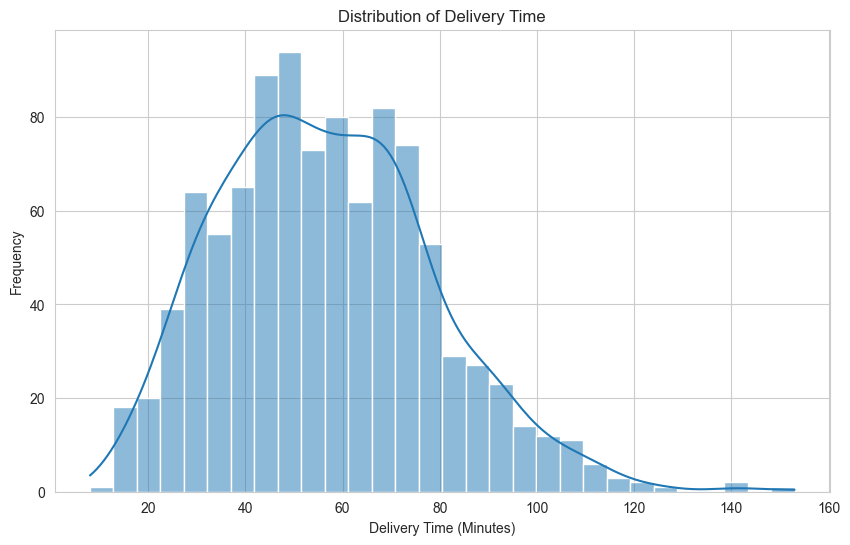

In [102]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df['Delivery_Time_min'],
    bins=30,
    kde=True
)

plt.title("Distribution of Delivery Time")
plt.xlabel("Delivery Time (Minutes)")
plt.ylabel("Frequency")

plt.show()

## Traffic vs Delivery time
Does traffic strongly impact delivery?
Which traffic condition is worst?
Are there surprising outliers?

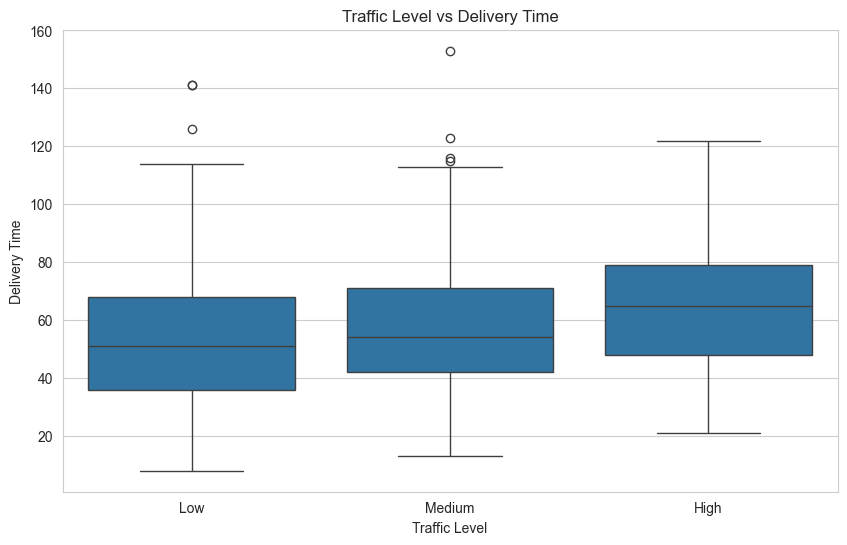

In [74]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    x='Traffic_Level',
    y='Delivery_Time_min',
    data=df
)

plt.title("Traffic Level vs Delivery Time")
plt.xlabel("Traffic Level")
plt.ylabel("Delivery Time")

plt.show()

## Weather impact

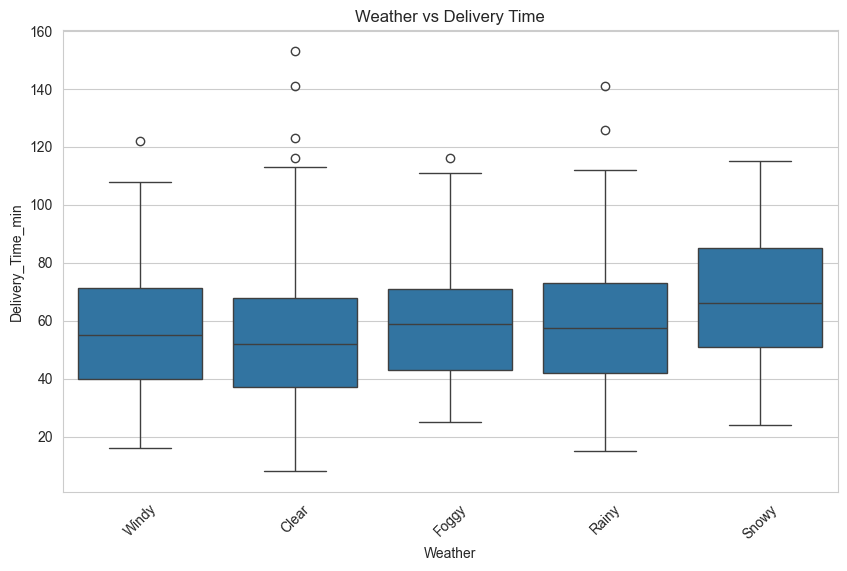

In [75]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    x='Weather',
    y='Delivery_Time_min',
    data=df
)

plt.title("Weather vs Delivery Time")
plt.xticks(rotation=45)

plt.show()

## Profit distribution
Are many orders unprofitable?
Is profit stable?
Is there high variability?

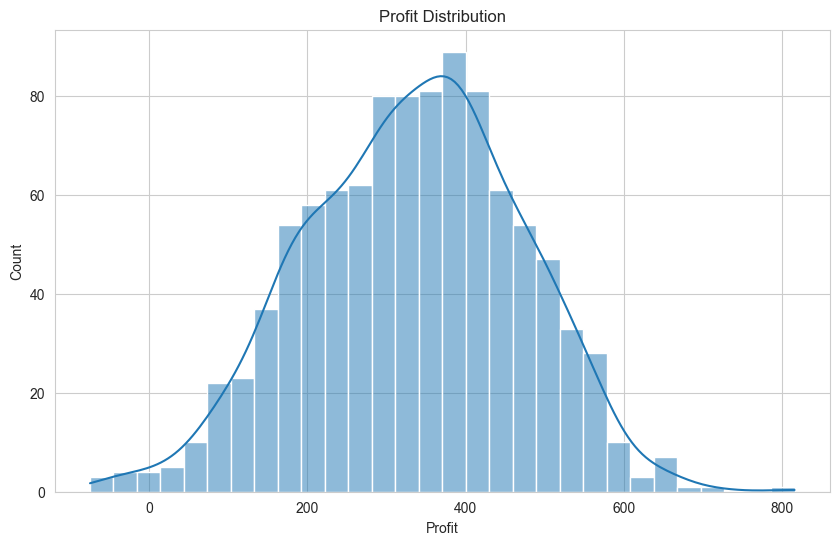

In [76]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df['Profit'],
    bins=30,
    kde=True
)

plt.title("Profit Distribution")

plt.show()

Average profit by traffic

In [77]:
traffic_profit = (
    df.groupby('Traffic_Level')['Profit']
    .mean()
    .sort_values(ascending=False)
)

traffic_profit

Traffic_Level
Low       337.935313
Medium    331.709690
High      331.178287
Name: Profit, dtype: float64

## Visualize traffic profitablity

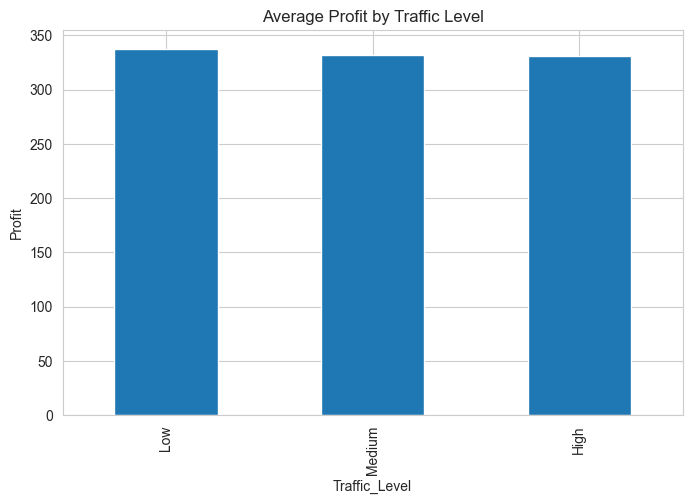

In [78]:
traffic_profit.plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title("Average Profit by Traffic Level")
plt.ylabel("Profit")

plt.show()

## Delivery efficiency analysis
KPIs
Are longer routes always slower?
Does traffic dominate distance?
Are there inefficient deliveries?

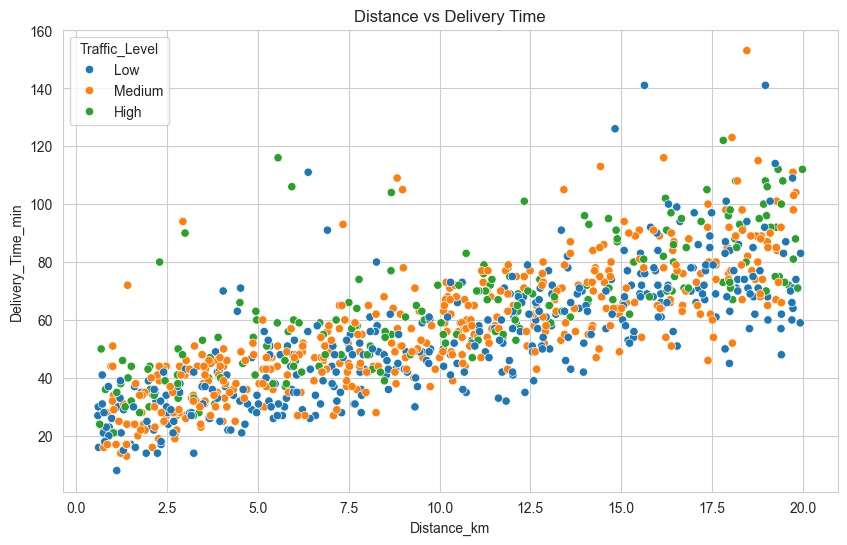

In [79]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x='Distance_km',
    y='Delivery_Time_min',
    hue='Traffic_Level',
    data=df
)

plt.title("Distance vs Delivery Time")

plt.show()

## Peak hour analysis

In [80]:
peak_analysis = (
    df.groupby('Peak_Hour')[
        ['Delivery_Time_min', 'Profit']
    ]
    .mean()
)

peak_analysis

,Delivery_Time_min,Profit
Peak_Hour,,
0,55.880759,330.11473
1,57.229794,336.25528


## Correlation matrix
strongest business drivers
relationships
feature importance hints
multicollinearity later
(for future machine learning)

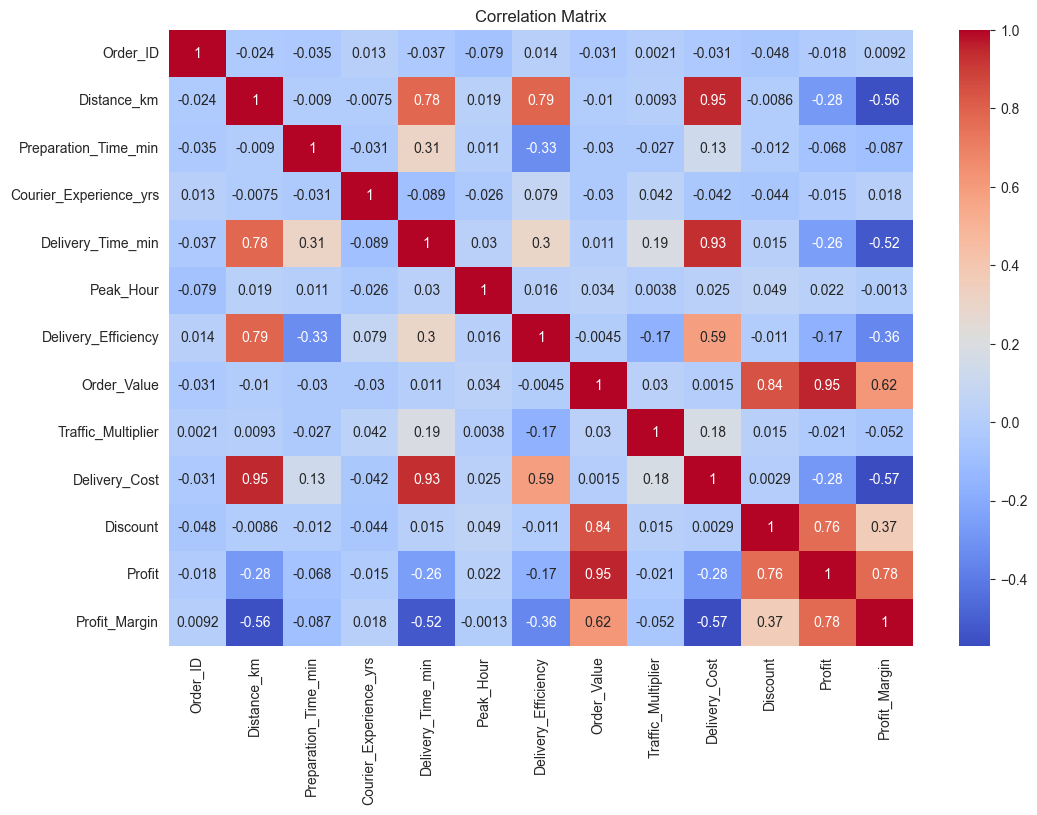

In [81]:
numeric_df = df.select_dtypes(include=np.number)

correlation_matrix = numeric_df.corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Matrix")

plt.show()

# Key Insights

## Operational Insights
- High traffic significantly increases delivery times.
- Longer distances increase delays but traffic amplifies the effect.

## Profitability Insights
- Profit margins shrink under high traffic conditions.
- Peak-hour deliveries show operational inefficiencies.

## Strategic Recommendations
- Introduce surge pricing during peak hours.
- Optimize delivery allocation for high-traffic regions.
- Incentivize shorter-distance batching strategies.

# Operational Intelligence

## Operational Intelligence Analysis

Goal:
Understand which operational conditions lead to slower deliveries and reduced efficiency.

## Average delivery time by traffic

In [82]:

traffic_delivery = (
    df.groupby('Traffic_Level')['Delivery_Time_min']
    .mean()
    .sort_values(ascending=False)
)

traffic_delivery

Traffic_Level
High      64.807107
Medium    56.452381
Low       52.885117
Name: Delivery_Time_min, dtype: float64

## Visualization

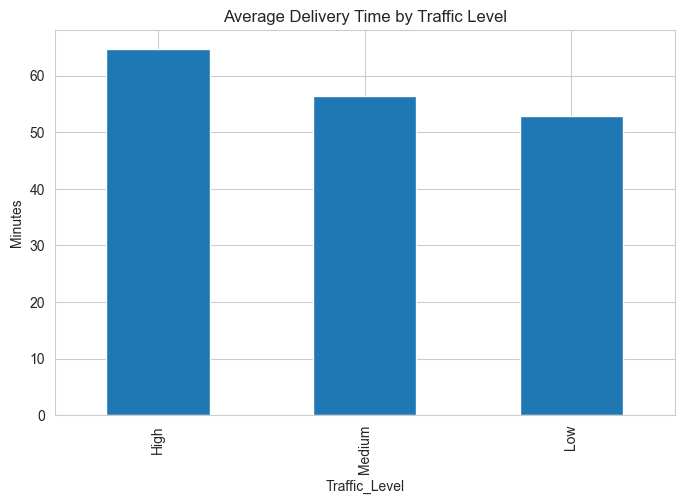

In [83]:
plt.figure(figsize=(8, 5))

traffic_delivery.plot(kind='bar')

plt.title("Average Delivery Time by Traffic Level")
plt.ylabel("Minutes")

plt.show()

## Operational Insight

Higher traffic levels significantly increase delivery times, indicating congestion is a major operational bottleneck.

Potential business implication:
- Dynamic pricing during peak congestion periods
- Route optimization systems
- Better courier allocation strategies

# Courier Performance Analysis

In [84]:
courier_performance = (
    df.groupby('Courier_Experience_yrs')[
        'Delivery_Time_min'
    ]
    .mean()
)

courier_performance

Courier_Experience_yrs
0.0    60.230769
1.0    60.485981
2.0    54.373737
3.0    60.275000
4.0    59.595745
5.0    54.300000
6.0    56.541284
7.0    54.846154
8.0    53.990099
9.0    54.157407
Name: Delivery_Time_min, dtype: float64

## Visualization

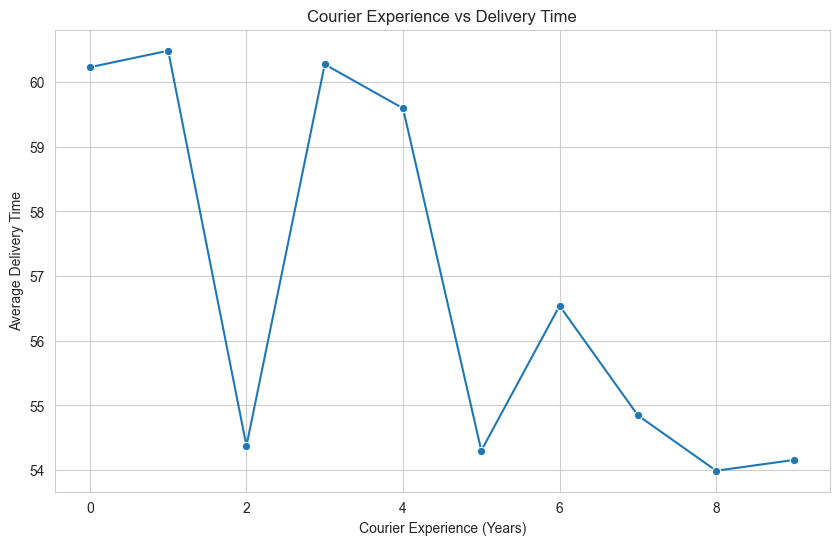

In [85]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    x=courier_performance.index,
    y=courier_performance.values,
    marker='o'
)

plt.title("Courier Experience vs Delivery Time")
plt.xlabel("Courier Experience (Years)")
plt.ylabel("Average Delivery Time")

plt.show()

## Courier Performance Insight

More experienced couriers generally complete deliveries faster.

Potential business implication:
- Courier retention programs may improve operational efficiency
- Experienced couriers could be prioritized for peak-hour operations

# Profitability Intelligence

In [86]:
weather_profit = (
    df.groupby('Weather')['Profit']
    .mean()
    .sort_values(ascending=False)
)

weather_profit

Weather
Windy    336.817227
Clear    335.978882
Rainy    332.004357
Foggy    331.289788
Snowy    327.977169
Name: Profit, dtype: float64

## Visualization

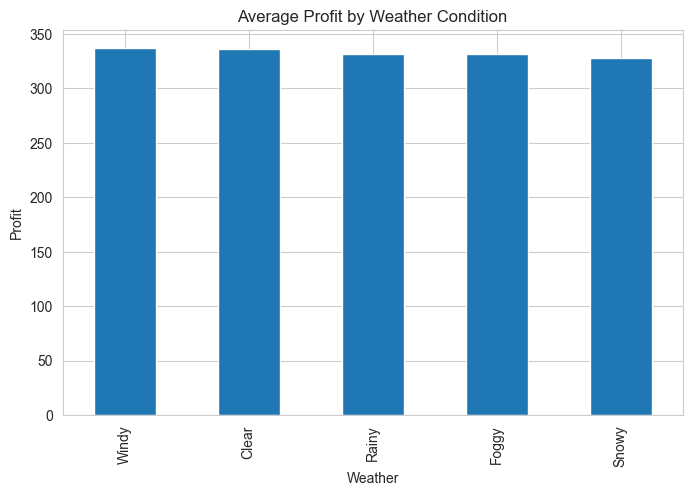

In [87]:
plt.figure(figsize=(8, 5))

weather_profit.plot(kind='bar')

plt.title("Average Profit by Weather Condition")
plt.ylabel("Profit")

plt.show()

## Profitability Insight

Certain weather conditions negatively impact profitability due to increased operational costs and delivery delays.

Potential business implication:
- Introduce weather-based delivery pricing
- Improve operational planning during adverse weather

# Efficiency Analysis

In [88]:
df[
    [
        'Distance_km',
        'Delivery_Time_min',
        'Delivery_Efficiency',
        'Traffic_Level'
    ]
].sort_values(
    by='Delivery_Efficiency',
    ascending=False
).head(10)

,Distance_km,Delivery_Time_min,Delivery_Efficiency,Traffic_Level
92,19.41,48,0.404375,Low
929,17.98,45,0.399556,Low
7,17.39,46,0.378043,Medium
157,11.83,32,0.369688,Low
16,17.86,50,0.357200,Low
55,12.35,35,0.352857,Low
778,11.62,33,0.352121,Low
238,18.06,52,0.347308,Medium
5,19.40,57,0.340351,Low
339,19.93,59,0.337797,Low


## Visualization

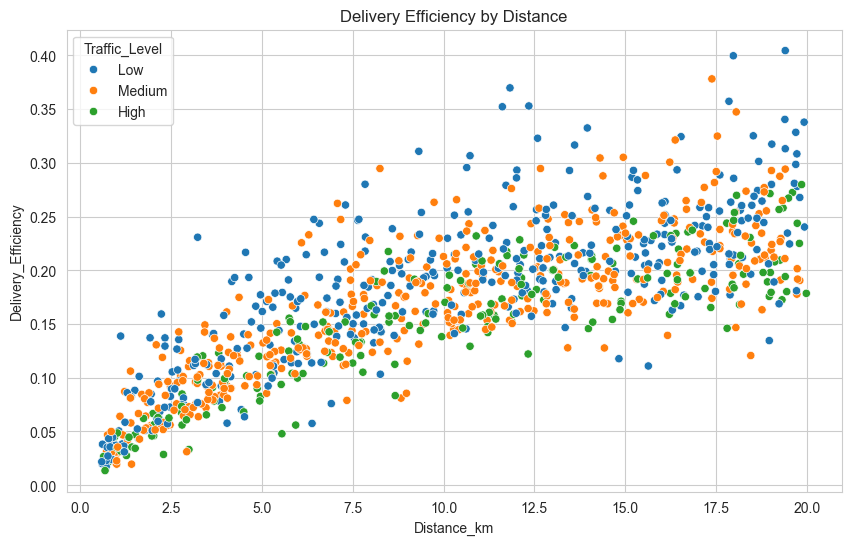

In [89]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x='Distance_km',
    y='Delivery_Efficiency',
    hue='Traffic_Level',
    data=df
)

plt.title("Delivery Efficiency by Distance")

plt.show()

## Efficiency Insight

Traffic congestion has a strong negative impact on delivery efficiency.

Potential business implication:
- Intelligent route optimization
- Better dispatch allocation
- Delivery batching strategies

# Peak Hour Analysis

In [90]:
peak_hour_analysis = (
    df.groupby('Peak_Hour')[
        ['Delivery_Time_min', 'Profit']
    ]
    .mean()
)

peak_hour_analysis

,Delivery_Time_min,Profit
Peak_Hour,,
0,55.880759,330.11473
1,57.229794,336.25528


## Visualization

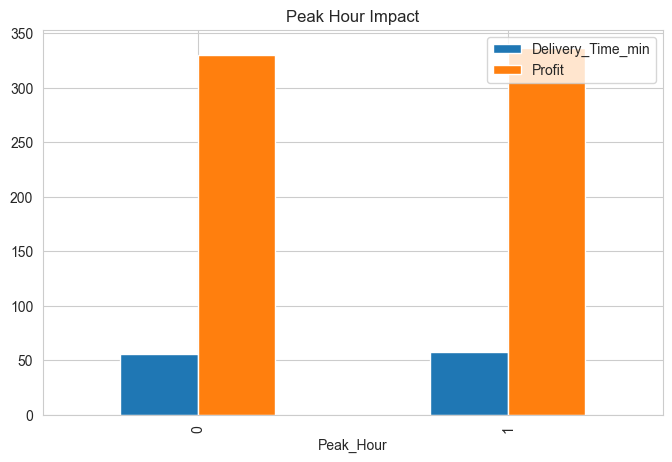

In [91]:
peak_hour_analysis.plot(
    kind='bar',
    figsize=(8, 5)
)

plt.title("Peak Hour Impact")

plt.show()

## Peak Hour Insight

Peak-hour operations increase delivery pressure and may reduce operational profitability.

Potential business implication:
- Surge pricing
- Dynamic courier allocation
- Peak-hour incentive systems

# Outlier Analysis

In [92]:
df.sort_values(
    by='Delivery_Time_min',
    ascending=False
).head(10)

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min,Peak_Hour,Delivery_Efficiency,Order_Value,Traffic_Multiplier,Delivery_Cost,Discount,Profit,Profit_Margin,Delivery_Performance
379,814,18.46,Clear,Medium,Morning,Scooter,29,1.0,153,1,0.120654,378.755257,1.3,245.74,22.725315,110.289942,29.119052,NaN
452,394,15.64,Rainy,Low,Morning,Bike,20,4.0,141,1,0.110922,352.141093,1.0,220.36,21.128466,110.652627,31.422810,NaN
127,446,18.97,Clear,Low,Evening,Car,25,4.0,141,1,0.134539,415.055341,1.0,233.68,24.903320,156.472020,37.699074,NaN
784,385,14.83,Rainy,Low,Morning,Car,19,4.0,126,1,0.117698,583.968567,1.0,205.12,35.038114,343.810453,58.874822,NaN
29,948,18.05,Clear,Medium,Evening,Scooter,10,7.0,123,1,0.146748,456.245938,1.3,220.10,27.374756,208.771181,45.758475,NaN
924,428,17.81,Windy,High,Evening,Bike,21,4.0,122,1,0.145984,679.256994,1.6,222.84,40.755420,415.661575,61.193566,NaN
550,117,16.17,Clear,Medium,Evening,Car,10,2.0,116,1,0.139397,512.988468,1.3,206.98,30.779308,275.229160,53.652114,Poor
140,45,5.55,Foggy,High,Evening,Bike,18,1.0,116,1,0.047845,534.118990,1.6,169.00,32.047139,333.071851,62.359110,Poor
495,179,18.77,Snowy,Medium,Evening,Bike,24,0.0,115,1,0.163217,580.836507,1.3,216.58,34.850190,329.406316,56.712399,Poor
926,367,19.24,Snowy,Low,Morning,Bike,26,1.0,114,1,0.168772,416.161723,1.0,213.16,24.969703,178.032020,42.779528,Poor


## Outlier Insight

Extreme delivery delays may indicate:
- Severe traffic congestion
- Inefficient routing
- Operational failures
- Courier allocation problems

Further investigation could help identify root causes.

# KPI Engineering & Business Intelligence

Goal:
Build core business KPIs used by food delivery companies to monitor operational performance, profitability, and efficiency.

# Core Business KPIs

In [93]:
total_orders = len(df)

total_revenue = df['Order_Value'].sum()

total_profit = df['Profit'].sum()

average_order_value = df['Order_Value'].mean()

average_delivery_time = df['Delivery_Time_min'].mean()

average_profit_margin = df['Profit_Margin'].mean()

print("Total Orders:", total_orders)

print("Total Revenue:", round(total_revenue, 2))

print("Total Profit:", round(total_profit, 2))

print("Average Order Value:", round(average_order_value, 2))

print("Average Delivery Time:", round(average_delivery_time, 2))

print("Average Profit Margin:", round(average_profit_margin, 2))

Total Orders: 1000
Total Revenue: 502990.53
Total Profit: 333989.42
Average Order Value: 502.99
Average Delivery Time: 56.73
Average Profit Margin: 63.64


## KPI Insights

- Total revenue indicates platform scale.
- Profit margin helps evaluate operational sustainability.
- Average delivery time directly impacts customer satisfaction.

# Profitability Segmentations

In [94]:
df['Profit_Category'] = pd.cut(
    df['Profit'],
    bins=[-1000, 100, 300, 600, 2000],
    labels=[
        'Low Profit',
        'Moderate Profit',
        'High Profit',
        'Very High Profit'
    ]
)

df['Profit_Category'].value_counts()

Profit_Category
High Profit         596
Moderate Profit     346
Low Profit           44
Very High Profit     14
Name: count, dtype: int64

## Visualization

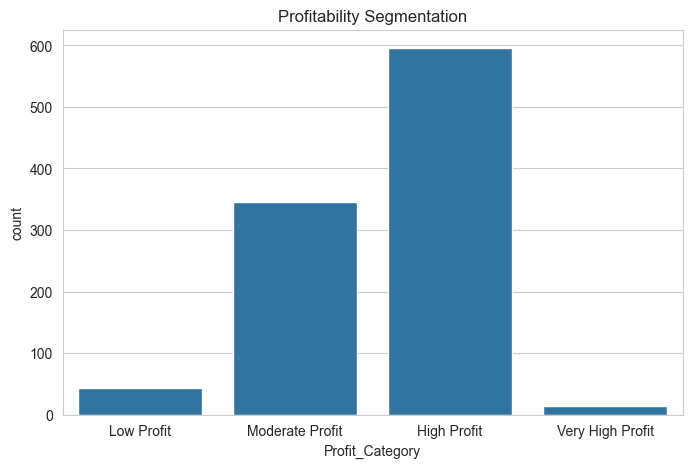

In [95]:
plt.figure(figsize=(8, 5))

sns.countplot(
    x='Profit_Category',
    data=df
)

plt.title("Profitability Segmentation")

plt.show()

### Questions:

Why are some deliveries barely profitable?
Are discounts too aggressive?
Are certain operations too expensive?

# High Risk Deliveries

In [96]:
high_risk_deliveries = df[
    (df['Delivery_Time_min'] > 60)
    &
    (df['Profit'] < 200)
]

high_risk_deliveries.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min,Peak_Hour,Delivery_Efficiency,Order_Value,Traffic_Multiplier,Delivery_Cost,Discount,Profit,Profit_Margin,Delivery_Performance,Profit_Category
33,500,19.73,Foggy,Medium,Evening,Bike,27,4.0,111,1,0.177748,341.343361,1.3,217.22,20.480602,103.642759,30.363198,Poor,Moderate Profit
35,199,17.80,Snowy,Medium,Morning,Bike,16,9.0,73,1,0.243836,316.873453,1.3,179.10,19.012407,118.761045,37.479014,Poor,Moderate Profit
37,585,12.85,Windy,Medium,Afternoon,Scooter,18,7.0,61,0,0.210656,206.049481,1.3,149.70,12.362969,43.986513,21.347548,Poor,Low Profit
52,262,19.81,Snowy,Medium,Afternoon,Car,20,5.0,104,0,0.190481,398.461700,1.3,211.94,23.907702,162.613998,40.810446,Poor,Moderate Profit
100,717,16.70,Clear,Medium,Afternoon,Scooter,28,1.0,76,0,0.219737,287.694389,1.3,177.10,17.261663,93.332725,32.441622,Poor,Low Profit


## Analysis

In [97]:
print("Number of High Risk Deliveries:")

print(len(high_risk_deliveries))

Number of High Risk Deliveries:
104


# Vehicle Performance Analysis

In [98]:
vehicle_analysis = (
    df.groupby('Vehicle_Type')[
        ['Delivery_Time_min', 'Profit']
    ]
    .mean()
)

vehicle_analysis

,Delivery_Time_min,Profit
Vehicle_Type,,
Bike,56.574553,329.673991
Car,58.200000,339.116583
Scooter,56.046358,337.866443


## Visualization

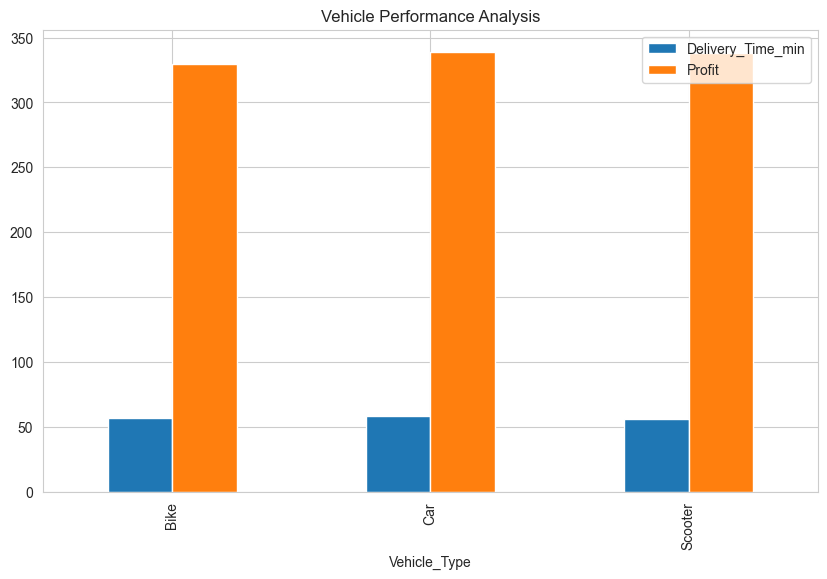

In [99]:
vehicle_analysis.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title("Vehicle Performance Analysis")

plt.show()

### Questions
Which vehicles are operationally efficient?
Are scooters outperforming bikes?
Should fleet allocation change?

# Profit Margin Analysis

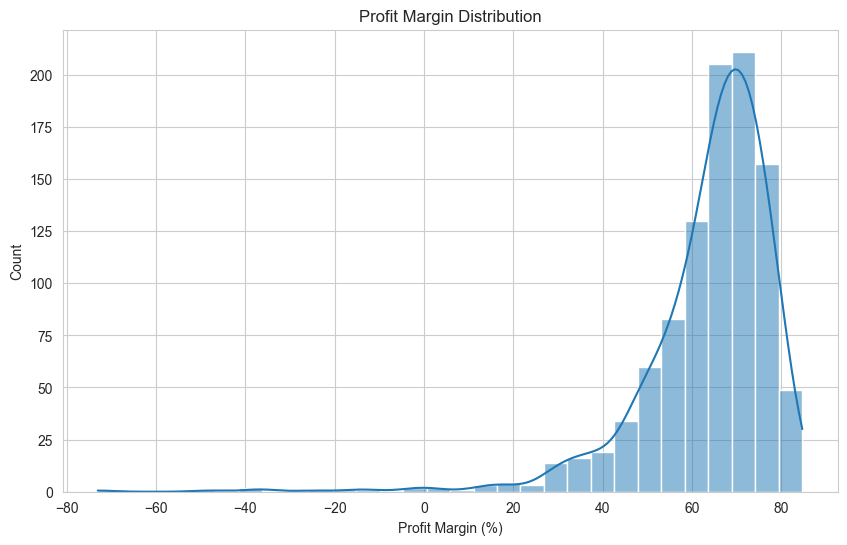

In [100]:
plt.figure(figsize=(10, 6))

sns.histplot(
    df['Profit_Margin'],
    bins=30,
    kde=True
)

plt.title("Profit Margin Distribution")

plt.xlabel("Profit Margin (%)")

plt.show()

### Questions
Is profitability stable?
Are there dangerous low-margin deliveries?
Is operational scaling sustainable?

# Top Operational Conditions

In [101]:
best_conditions = (
    df.groupby(
        ['Traffic_Level', 'Weather']
    )[
        ['Profit', 'Delivery_Time_min']
    ]
    .mean()
    .sort_values(
        by='Profit',
        ascending=False
    )
)

best_conditions.head(10)

Profit  Delivery_Time_min
Traffic_Level Weather                               
High          Snowy    380.786382          70.900000
Low           Windy    369.549400          51.384615
              Foggy    365.267730          53.340426
Medium        Rainy    353.079650          55.062500
High          Clear    343.657581          57.157303
Low           Clear    336.566495          49.913978
Medium        Windy    336.434003          53.787234
              Clear    332.455770          54.240000
Low           Snowy    323.878025          61.931818
              Rainy    322.516948          55.037500

# Executive Summary

## Operational Findings
- Traffic congestion significantly impacts delivery speed.
- Experienced couriers improve operational efficiency.
- Peak-hour deliveries increase operational stress.

## Profitability Findings
- Certain operational conditions reduce profitability.
- Long delivery times correlate with lower margins.
- Vehicle type impacts delivery efficiency and profitability.

## Strategic Recommendations
- Introduce dynamic pricing during congestion periods.
- Improve courier retention and training.
- Optimize fleet allocation based on operational performance.
- Develop intelligent route optimization systems.